### 07 - Comparaison de Modeles de Regression
#### HumanForYou - Attrition ML

Objectif : comparer plusieurs modeles de regression sur le dataset housing prepare et produire un classement de performance.

- **Entrees** : `data/processed/housing_train_prepared.csv`, `data/processed/housing_test_prepared.csv`
- **Sorties** : `data/processed/housing_model_comparison.csv`, `data/processed/housing_model_predictions_test.csv`


#### 1. Imports et chemins

Cette cellule importe les modeles, metriques et outils de validation croisee utilises pour la comparaison.


In [8]:
# Imports principaux pour comparer plusieurs modeles de regression.
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor


#### 2. Chargement des jeux train/test

Cette etape recupere les datasets preprocesses et separe les features de la cible.


In [9]:
# Chargement des jeux prepares depuis data/processed.
PROCESSED_DIR = os.path.join('..', 'data', 'processed')
train_path = os.path.join(PROCESSED_DIR, 'housing_train_prepared.csv')
test_path = os.path.join(PROCESSED_DIR, 'housing_test_prepared.csv')

assert os.path.exists(train_path), f'Fichier introuvable: {train_path}'
assert os.path.exists(test_path), f'Fichier introuvable: {test_path}'

train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

X_train = train_df.drop(columns=['median_house_value']).copy()
y_train = train_df['median_house_value'].copy()
X_test = test_df.drop(columns=['median_house_value']).copy()
y_test = test_df['median_house_value'].copy()

print(f'X_train: {X_train.shape}, X_test: {X_test.shape}')


X_train: (16512, 16), X_test: (4128, 16)


#### 3. Validation croisee (RMSE)

Cette section calcule la RMSE en validation croisee pour disposer d'un premier signal robuste avant evaluation test.


In [10]:
# Evaluation CV de plusieurs modeles sur le jeu train avec un cout de calcul maitrise.
cv_models = {
    'LinearRegression': LinearRegression(),
    'DecisionTreeRegressor': DecisionTreeRegressor(random_state=42),
    'RandomForestRegressor': RandomForestRegressor(n_estimators=120, random_state=42, n_jobs=-1),
}

cv_rows = []
for model_name, model in cv_models.items():
    cv_scores = cross_val_score(
        model,
        X_train,
        y_train,
        scoring='neg_root_mean_squared_error',
        cv=3,
        n_jobs=-1,
    )
    rmse_scores = -cv_scores
    cv_rows.append({
        'model': model_name,
        'rmse_cv_mean': float(rmse_scores.mean()),
        'rmse_cv_std': float(rmse_scores.std()),
    })

cv_df = pd.DataFrame(cv_rows).sort_values('rmse_cv_mean')
cv_df


,model,rmse_cv_mean,rmse_cv_std
2,RandomForestRegressor,51209.332214,923.734166
0,LinearRegression,68568.863151,866.314317
1,DecisionTreeRegressor,72536.814361,1342.000583


#### 4. Entrainement final et comparaison test

Ici, chaque modele est entraine sur train puis evalue sur test pour etablir un classement final.


In [11]:
# Entrainement des modeles et comparaison via RMSE/R2 sur le jeu test.
models = {
    'LinearRegression': LinearRegression(),
    'DecisionTreeRegressor': DecisionTreeRegressor(random_state=42),
    'RandomForestRegressor': RandomForestRegressor(n_estimators=180, random_state=42, n_jobs=-1),
    'SVR_RBF': SVR(kernel='rbf', C=50.0, epsilon=0.2),
    'KNeighborsRegressor': KNeighborsRegressor(n_neighbors=8),
}

comparison_rows = []
predictions_df = pd.DataFrame({'y_true': y_test})

# SVR est couteux: on l'entraine sur un sous-echantillon train pour garder le notebook fluide.
rng = np.random.RandomState(42)
svr_sample_size = min(4000, len(X_train))
svr_sample_idx = rng.choice(len(X_train), size=svr_sample_size, replace=False)

for model_name, model in models.items():
    if model_name == 'SVR_RBF':
        X_fit = X_train.iloc[svr_sample_idx]
        y_fit = y_train.iloc[svr_sample_idx]
        model.fit(X_fit, y_fit)
        y_pred_train = model.predict(X_fit)
        y_true_train = y_fit
    else:
        model.fit(X_train, y_train)
        y_pred_train = model.predict(X_train)
        y_true_train = y_train

    y_pred_test = model.predict(X_test)

    comparison_rows.append({
        'model': model_name,
        'rmse_train': float(np.sqrt(mean_squared_error(y_true_train, y_pred_train))),
        'r2_train': float(r2_score(y_true_train, y_pred_train)),
        'rmse_test': float(np.sqrt(mean_squared_error(y_test, y_pred_test))),
        'r2_test': float(r2_score(y_test, y_pred_test)),
        'train_sample': int(len(y_true_train)),
    })

    predictions_df[f'pred_{model_name}'] = y_pred_test

comparison_df = pd.DataFrame(comparison_rows).sort_values('rmse_test')
comparison_df


,model,rmse_train,r2_train,rmse_test,r2_test,train_sample
2,RandomForestRegressor,18485.987239,0.974471,48110.070980,0.822408,16512
4,KNeighborsRegressor,53482.294846,0.786317,59422.624890,0.729072,16512
0,LinearRegression,68160.924355,0.652927,66803.138908,0.657592,16512
1,DecisionTreeRegressor,0.000000,1.000000,70467.151243,0.619001,16512
3,SVR_RBF,114054.031019,0.018743,112953.017869,0.021082,4000


#### 5. Visualisations de comparaison

Cette partie genere les figures de synthese pour comparer les performances et visualiser le meilleur modele.


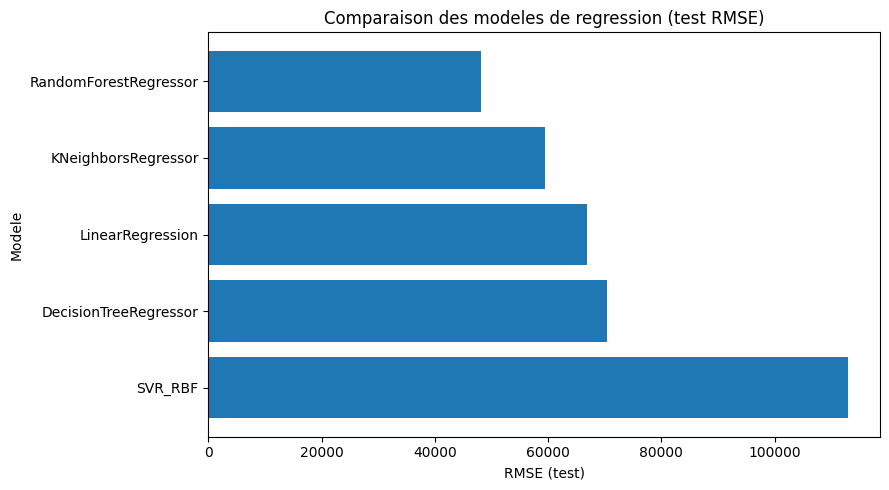

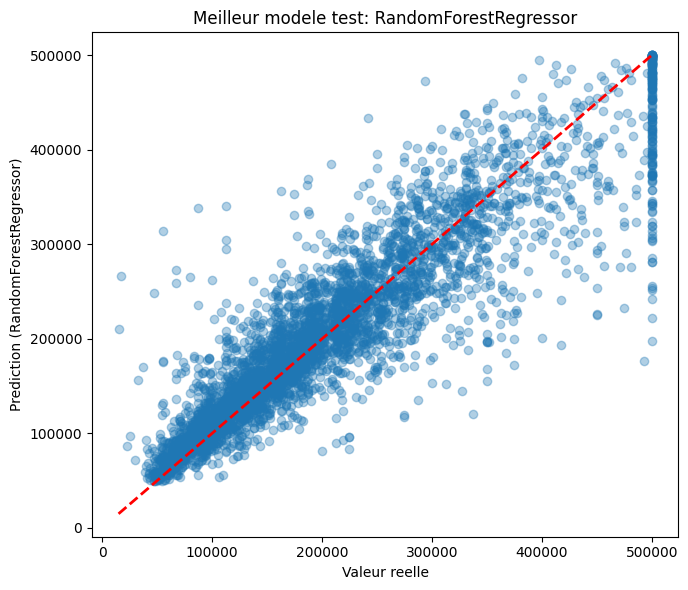

Saved: ..\reports\figures\regression_models_rmse_comparison.png
Saved: ..\reports\figures\regression_best_model_actual_vs_pred.png


In [12]:
# Creation des figures de comparaison et du scatter du meilleur modele.
FIG_DIR = os.path.join('..', 'reports', 'figures')
os.makedirs(FIG_DIR, exist_ok=True)

plt.figure(figsize=(9, 5))
plot_df = comparison_df.sort_values('rmse_test', ascending=False)
plt.barh(plot_df['model'], plot_df['rmse_test'])
plt.xlabel('RMSE (test)')
plt.ylabel('Modele')
plt.title('Comparaison des modeles de regression (test RMSE)')
plt.tight_layout()
rmse_fig_path = os.path.join(FIG_DIR, 'regression_models_rmse_comparison.png')
plt.savefig(rmse_fig_path, dpi=300)
plt.show()

best_model_name = comparison_df.iloc[0]['model']
best_pred_col = f'pred_{best_model_name}'

plt.figure(figsize=(7, 6))
plt.scatter(predictions_df['y_true'], predictions_df[best_pred_col], alpha=0.35)
min_val = min(predictions_df['y_true'].min(), predictions_df[best_pred_col].min())
max_val = max(predictions_df['y_true'].max(), predictions_df[best_pred_col].max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2)
plt.xlabel('Valeur reelle')
plt.ylabel(f'Prediction ({best_model_name})')
plt.title(f'Meilleur modele test: {best_model_name}')
plt.tight_layout()
best_fig_path = os.path.join(FIG_DIR, 'regression_best_model_actual_vs_pred.png')
plt.savefig(best_fig_path, dpi=300)
plt.show()

print(f'Saved: {rmse_fig_path}')
print(f'Saved: {best_fig_path}')


#### 6. Export des resultats

Cette cellule exporte les tableaux de comparaison et de predictions test.


In [13]:
# Export des resultats pour reutilisation dans un rapport ou une presentation.
comparison_path = os.path.join(PROCESSED_DIR, 'housing_model_comparison.csv')
predictions_path = os.path.join(PROCESSED_DIR, 'housing_model_predictions_test.csv')
cv_path = os.path.join(PROCESSED_DIR, 'housing_model_cv_scores.csv')

comparison_df.to_csv(comparison_path, index=False)
predictions_df.to_csv(predictions_path, index=False)
cv_df.to_csv(cv_path, index=False)

print(f'Saved: {comparison_path}')
print(f'Saved: {predictions_path}')
print(f'Saved: {cv_path}')


Saved: ..\data\processed\housing_model_comparison.csv
Saved: ..\data\processed\housing_model_predictions_test.csv
Saved: ..\data\processed\housing_model_cv_scores.csv


#### 7. Validation

Cette cellule verifie la presence des fichiers exportes et la coherence des colonnes principales.


In [14]:
# Verifications finales pour garantir la validite des sorties produites.
assert os.path.exists(comparison_path), 'Fichier comparison manquant'
assert os.path.exists(predictions_path), 'Fichier predictions manquant'
assert os.path.exists(cv_path), 'Fichier CV manquant'
assert {'model', 'rmse_test', 'r2_test'}.issubset(comparison_df.columns), 'Colonnes comparison incompletes'
assert predictions_df.shape[0] == y_test.shape[0], 'Nombre de predictions incoherent'

print('Validation OK pour 07_Regression_Comparaison_Modeles.ipynb')


Validation OK pour 07_Regression_Comparaison_Modeles.ipynb
